# Home Assignment 1

## Problem 1 (1 point). My Hashrate

This is a simple implemetation of Proof-of-Work function.
It takes current block header and block calculation difficulty as inputs and returns nonce for this block and the header of a mined block.

In [5]:
import hashlib

def proof_of_work(header, target):
    max_nonce = 2 ** 32
    for nonce in range(max_nonce):
        hash_result = hashlib.sha256(str(header).encode('utf-8')+str(nonce).encode('utf-8')).hexdigest()

        if int(hash_result, 16) < target:
            return (hash_result, nonce)

The genesis block is calulated here.

In [ ]:
import time

nonce = 0
block_hash = ""
new_block = 'This is the genesis block' + block_hash

difficulty_bits = 8
target = 2 ** (256-difficulty_bits) # то есть, число выглядит как 00000001000...000, отступаем 7 бит в начале, а после 256 - 8 = 248 нулей

start_time = time.time()
(block_hash, nonce) = proof_of_work(new_block, target)
end_time = time.time()
elapsed_time = end_time - start_time

print("Success with nonce ", nonce)
print("Hash is ", block_hash)
print("Elapsed time: %.4f seconds" % elapsed_time)

Success with nonce  186
Hash is  005eaab75f55d7cef91c03f04052043056113f6ee14abfcf4a0562a019aa1cbe
Elapsed time: 0.0002 seconds


### Task

Choose such a target that you will calculated 20 160 000 blocks per 14 days in avarage. Prove it experimetally (estimate time for at least 1000 blocks; compute both mean and standard deviation of a single block generation).

*Note.* Each next block should be calculated using the hash of the previous one.

In [19]:
# code here 

import numpy as np 
import math 

# 14 дней = 1,209,600 секунд
# то есть хотим 20,160,000 / 1,209,600 = 0.06 блоков в секунду 

def mine_chain(difficulty_bits, num_blocks=1000, genesis_block_hash=""):
    """Mine a chain of `num_blocks`, each using prev block hash. Returns list of times."""
    times = []
    target = 2 ** (256 - difficulty_bits)
    block_hash = genesis_block_hash
    for i in range(1, num_blocks):
        new_block = f'block_{i} ' + block_hash
        start = time.time()
        (block_hash, nonce) = proof_of_work(new_block, target)
        times.append(time.time() - start)
    return times

# Сколько времени займет майнинг 200 блоков при сложности = 8 ? 
times = mine_chain(difficulty_bits=8, num_blocks=200, genesis_block_hash=block_hash)
mean_t_8 = np.mean(times)
print(f"Difficulty 8, 200 block sample: E = {mean_t_8:.6f} seconds. std = {np.std(times):.6f}") 

# Вероятность получить валидный хеш = 2 ^ (256 - отступ) / 2 ^ 256 = 2 ^ (-отступ) 
# Поэтому время поиска хеша пропорционально 1 / 2 ^ (-отступ) =  2 ^ (+отступ) тк это геометрическое распределение 
# Если x = искомый отступ, то 
# T(x) / T(8) = 2 ^ (x) / 2 ^ (8) = 2 ^ (x - 8) 
# T(X) = T(8) * 2 ^ (x - 8)  

mean_t_8 = np.mean(times) 
needed_d = 8 + math.log2(0.06 / mean_t_8) 
difficulty_bits = int(round(needed_d))
print(f"Target difficulty = {difficulty_bits:.2f}") 


Difficulty 8, 200 block sample: E = 0.000165 seconds. std = 0.000183
Target difficulty = 17.00


In [ ]:
# Trying 17 bits. Turns out, the blocks are generating faster (0.046 s instead of 0.06s)
difficulty_bits = 17

times = mine_chain(difficulty_bits, num_blocks=1000)

mean = np.mean(times)
std = np.std(times)
print(f"Difficulty {difficulty_bits}, 1000 block sample:")
print(f"  E = {mean:.6f} s   (target 0.06 s)")
print(f"  std  = {std:.6f}")

# Projected blocks per 14 days
blocks_per_14d = 14 * 24 * 3600 / mean
print(f"  projected blocks / 14 days = {blocks_per_14d:,.0f}")

Difficulty 17, 1000 block sample:
  E = 0.046103 s   (target 0.06 s)
  std  = 0.045081
  projected blocks / 14 days = 26,236,971


In [ ]:
# Trying 18 bits. Here, the estimated time is already more (0.09s per block) 
difficulty_bits = 18

times = mine_chain(difficulty_bits, num_blocks=1000)

mean = np.mean(times)
std = np.std(times)
print(f"Difficulty {difficulty_bits}, 1000 block sample:")
print(f"  E = {mean:.6f} s   (target 0.06 s)")
print(f"  std  = {std:.6f}")

# Projected blocks per 14 days
blocks_per_14d = 14 * 24 * 3600 / mean
print(f"  projected blocks / 14 days = {blocks_per_14d:,.0f}")

Difficulty 18, 1000 block sample:
  E = 0.092513 s   (target 0.06 s)
  std  = 0.092225
  projected blocks / 14 days = 13,074,921


### Problem 1. Answer: "target = 17 bits". 
We will get about 26 million blocks in two weeks.   

If choosing Target = 18 bits, we will get only 13 million blocks in two weeks (which is too little). 

#### Problem 2 (4 points). Merkle tree

Merkle hash trees play an important role in forming transaction blocks in blockchain. In this assignment we ask you to plot your own Merkle hash tree and check its' properties. Below we provide you with some code fragment what you can use in your assignment

In [38]:
import matplotlib 
import matplotlib.pyplot as plt
import networkx as nx
# %matplotlib qt5 
%matplotlib inline
from networkx import balanced_tree, draw_networkx, draw

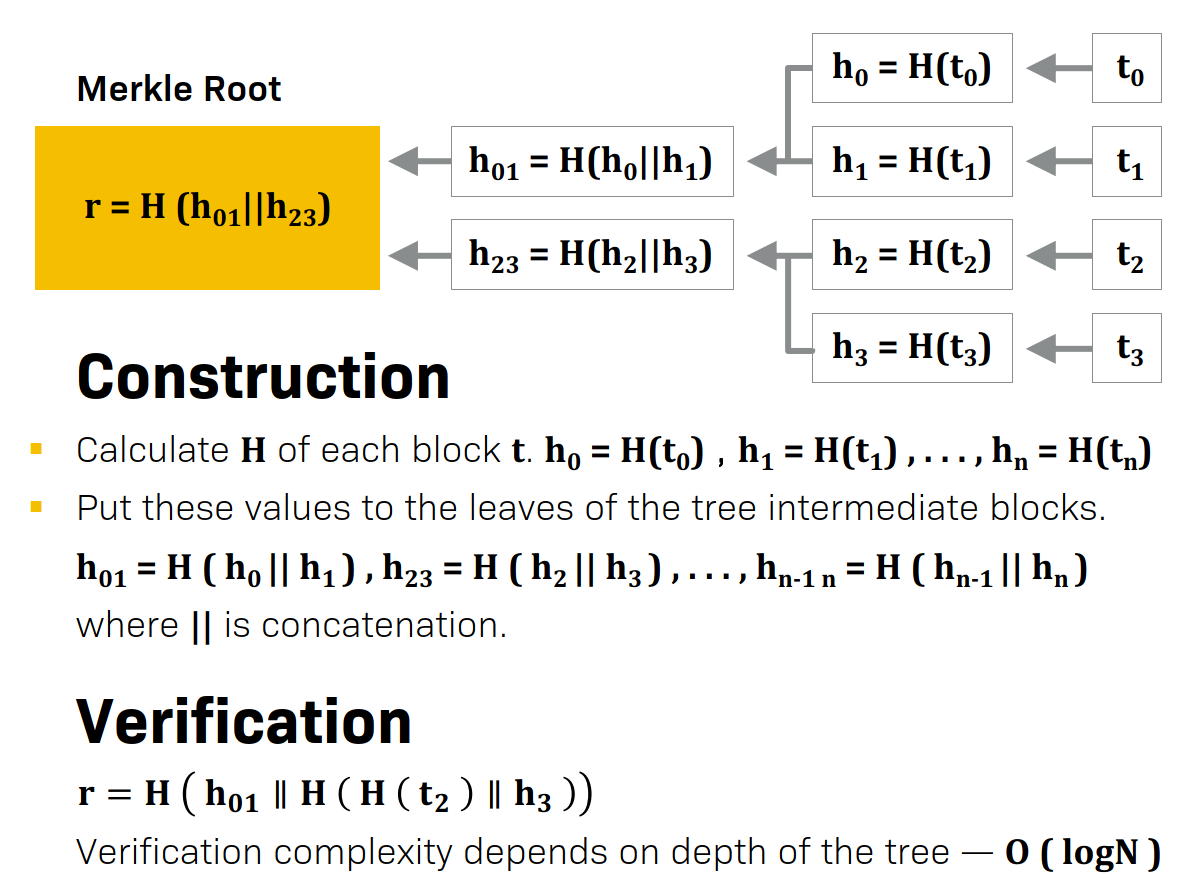

Let us plot graph basis for Merkle hash tree

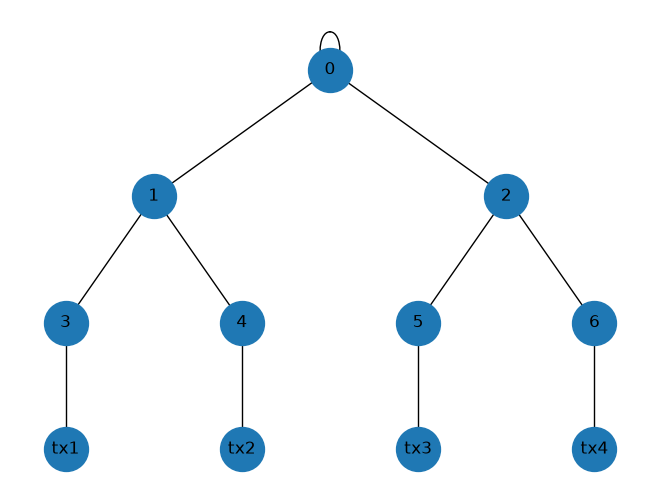

In [45]:
G = nx.Graph()
positions = {}
coordinates = [
    [0, 4],
    [-2, 3],
    [2, 3],
    [-3, 2],
    [-1, 2],
    [1, 2],
    [3, 2],
    [-3, 1],
    [-1, 1],
    [1, 1],
    [3, 1]
]
parents = [0, 0, 0, 1, 1, 2, 2, 3, 4, 5, 6]
for index in range(11):
    G.add_node(index)
    G.add_edge(index, parents[index])
    positions[index] = coordinates[index]
nx.draw(G, positions, node_size = 1000)
labels = {
    0: '0',
    1: '1',
    2: '2',
    3: '3',
    4: '4',
    5: '5',
    6: '6',
    7: 'tx1',
    8: 'tx2',
    9: 'tx3',
    10: 'tx4',
}
nx.draw_networkx_labels(G, positions, labels = labels) 

plt.show()

In Bitcoin double sha256 hash scheme is used. Here is an example.

In [ ]:
import hashlib


first_hash = hashlib.sha256(b"hello") # "b" stands for binary representation
second_hash = hashlib.sha256()
print('First hash represented as a hexadecimal number:', first_hash.hexdigest()) # 64 digits 
second_hash.update(first_hash.digest()) 
print('Second hash represented as a hexadecimal number:', second_hash.hexdigest())

First hash represented as a hexadecimal number: 2cf24dba5fb0a30e26e83b2ac5b9e29e1b161e5c1fa7425e73043362938b9824
Second hash represented as a hexadecimal number: 9595c9df90075148eb06860365df33584b75bff782a510c6cd4883a419833d50


Now we can easily change vertices' labels to hashes of corresponding messages and plot new graph

[]

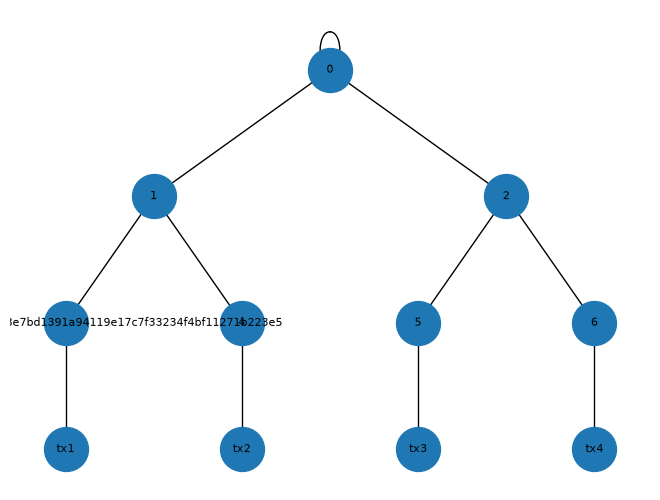

In [48]:
labels[3] = hashlib.sha256(hashlib.sha256(b"tx1").digest()).hexdigest()

# and plot the graph again

nx.draw(G, positions, node_size = 1000)
nx.draw_networkx_labels(G, positions, labels = labels, font_size = 8) 

plt.plot()

1) Construct Merkle hash tree using previously constructed graph by finding corresponding SHA256 hashes on vertices and plot obtained Merkle hash tree (1 point)

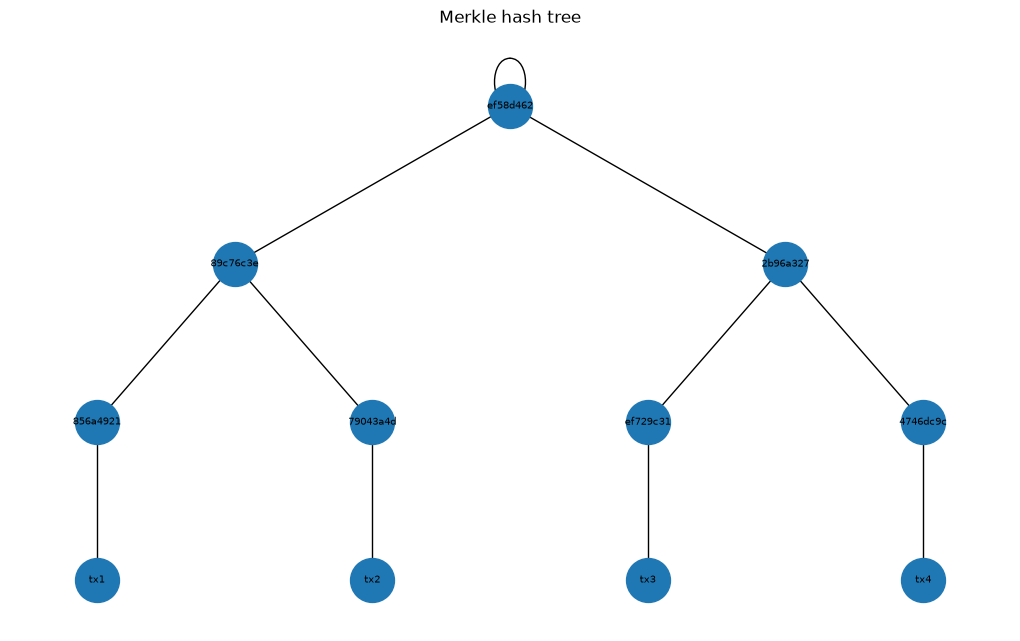

In [ ]:
# code 

def double_sha256(data: bytes) -> bytes:
    """Bitcoin-style hash: sha256(sha256(data)). Returns raw bytes."""
    return hashlib.sha256(hashlib.sha256(data).digest()).digest()

def hash_pair(a: bytes, b: bytes) -> bytes:
    """Combine two child hashes into a parent hash."""
    return double_sha256(a + b) 

leaves = {3: b"tx1", 4: b"tx2", 5: b"tx3", 6: b"tx4"}

hashes = {}
for node, val in leaves.items():
    hashes[node] = double_sha256(val) 

# children[node] = list of child node indices
children = {i: [] for i in range(7)}
for child in range(1, 7):
    children[parents[child]].append(child)

# Process nodes from leaves to the root 
for node in range(6, -1, -1):
    if node in hashes:          # already a leaf
        continue
    kids = children[node]
    if len(kids) == 1:
        # if a single child, hash it with itself
        hashes[node] = hash_pair(hashes[kids[0]], hashes[kids[0]])
    else:
        # if multiple children, then combine left to right
        h = hashes[kids[0]]
        for k in kids[1:]:
            h = hash_pair(h, hashes[k])
        hashes[node] = h 

base = {7: b"tx1", 8: b"tx2", 9: b"tx3", 10: b"tx4"}
labels = {}
for n in range(11):
    if n in base:
        labels[n] = base[n].decode()
    else:
        labels[n] = hashes[n].hex()[:8]    # Displaying just first 8 characters (otherwise it is too big) 

plt.figure(figsize=(10, 6))
nx.draw(G, positions, node_size=1000, with_labels=False)
nx.draw_networkx_labels(G, positions, labels=labels, font_size=7)
plt.title("Merkle hash tree")
plt.show() 


2) Provide a proof of correctness of leaf tx1 and set of leafs tx1-tx2 (1 point)

In [60]:
# code 

# mapping: node - parent 
def build_parent_map(children):
    parent = {}
    for p, kids in children.items():
        for k in kids:
            parent[k] = p
    return parent

def merkle_proof(leaf_node, children, hashes):
    """List (child_hash, True if the child is on the left) from leaf up to root."""
    parent = build_parent_map(children)
    proof = []
    cur = leaf_node
    while cur in parent:
        p = parent[cur]
        child_list = [k for k in children[p] if k != cur]
        if len(child_list) == 1: # we just have a binary tree 
            child = child_list[0]
            proof.append((hashes[child], child < cur))
        else: # if only Child, then break
            break
        cur = p
    return proof

def verify_merkle_proof(leaf_hash, proof, expected_root):
    h = leaf_hash
    for child, flag in proof: # if flag=True, then child is on the left 
        h = hash_pair(child, h) if flag else hash_pair(h, child)
    return h == expected_root 

root = hashes[0]

proof_tx1 = merkle_proof(3, children, hashes)
ok_tx1 = verify_merkle_proof(hashes[3], proof_tx1, root)
print("tx1 valid:", ok_tx1)

proof_tx2 = merkle_proof(4, children, hashes)
ok_tx2 = verify_merkle_proof(hashes[4], proof_tx2, root)
print("tx2 valid:", ok_tx2)

ok_set = ok_tx1 and ok_tx2
print("set {tx1, tx2} valid:", ok_set) 

tx1 valid: True
tx2 valid: True
set {tx1, tx2} valid: True


3) Change the value on leaf tx1 and recompute corresponding hashes. Plot newly obtained Merkle hash tree (1 point)

In [67]:
# code 

# --- original tree 
hashes = {3: double_sha256(b"tx1"),
          4: double_sha256(b"tx2"),
          5: double_sha256(b"tx3"),
          6: double_sha256(b"tx4")}
for node in range(2, -1, -1):
    kids = children[node]
    hashes[node] = hash_pair(hashes[kids[0]], hashes[kids[1]])

# --- modified tree 
hashes_new = {3: double_sha256(b"tx1_new"),
              4: double_sha256(b"tx2"),
              5: double_sha256(b"tx3"),
              6: double_sha256(b"tx4")}
for node in range(2, -1, -1):
    kids = children[node]
    hashes_new[node] = hash_pair(hashes_new[kids[0]], hashes_new[kids[1]])

# --- which nodes changed? 
print("node  old        new        changed?")
for n in sorted(hashes):
    old = hashes[n].hex()[:8]
    new = hashes_new[n].hex()[:8]
    flag = "YES" if hashes[n] != hashes_new[n] else "NO"
    print(f"{n:>3}   {old}   {new}   {flag}") 

node  old        new        changed?
  0   ef58d462   120cd28a   YES
  1   89c76c3e   3943cce6   YES
  2   2b96a327   2b96a327   NO
  3   856a4921   438f7482   YES
  4   79043a4d   79043a4d   NO
  5   ef729c31   ef729c31   NO
  6   4746dc9c   4746dc9c   NO


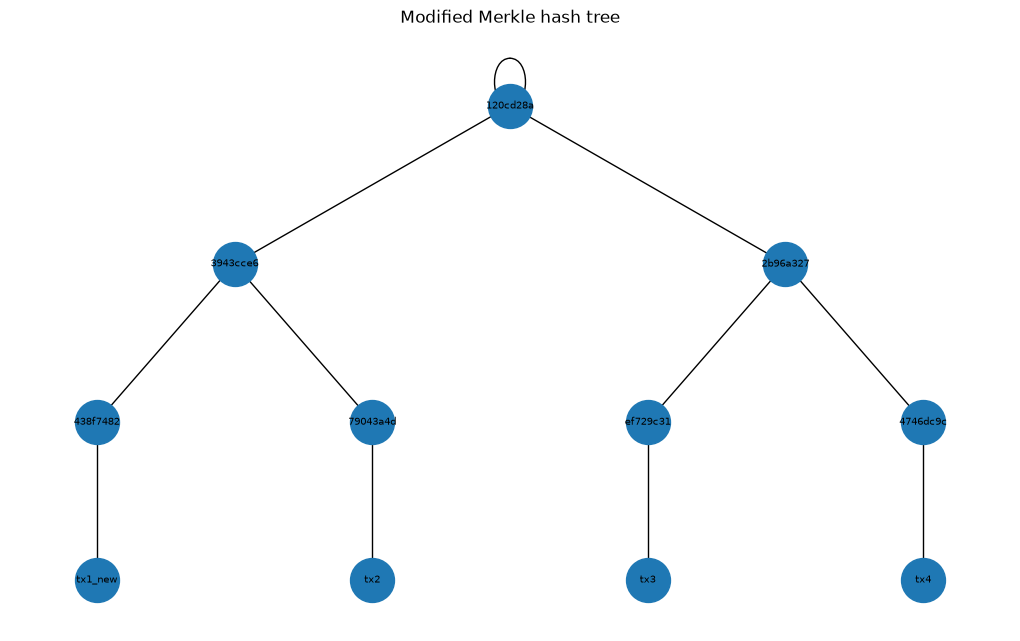

In [69]:
base = {7: b"tx1_new", 8: b"tx2", 9: b"tx3", 10: b"tx4"}
labels = {}
for n in range(11):
    if n in base:
        labels[n] = base[n].decode()
    else:
        labels[n] = hashes_new[n].hex()[:8]    # Displaying just first 8 characters (otherwise it is too big) 

plt.figure(figsize=(10, 6))
nx.draw(G, positions, node_size=1000, with_labels=False)
nx.draw_networkx_labels(G, positions, labels=labels, font_size=7)
plt.title("Modified Merkle hash tree")
plt.show() 

4) Implement a function to support the number of leafs $n =5, .., 16$. Let the value in the leaf $i$ be $txi$. Plot the tree. Provide the proof of correctness of leaf tx4 and set of leafs tx4-tx5 

In [75]:
# code 

def build_merkle(leaf_vals):
    """leaf_vals: list of bytes. Returns (children, hashes, root, leaf_ids)."""
    n = len(leaf_vals)
    hashes = {i: double_sha256(v) for i, v in enumerate(leaf_vals)}   # leaf ids 0..n-1
    children = {}
    level = list(range(n))
    nxt = n
    while len(level) > 1:
        if len(level) % 2:                                # pad odd level
            level.append(level[-1])
        new = []
        for i in range(0, len(level), 2):
            a, b = level[i], level[i + 1]
            hashes[nxt] = hash_pair(hashes[a], hashes[b])
            children[nxt] = [a, b]
            new.append(nxt) 
            nxt += 1
        level = new
    return children, hashes, level[0]

def merkle_proof(leaf, children, hashes, root):
    parent = {k: p for p, ks in children.items() for k in ks}
    proof, cur = [], leaf
    while cur != root:
        p = parent[cur]
        a, b = children[p]
        sib = b if a == cur else a
        proof.append((hashes[sib], sib < cur))
        cur = p
    return proof

def verify(leaf_hash, proof, root_hash):
    h = leaf_hash
    for sib, sib_left in proof:
        h = hash_pair(sib, h) if sib_left else hash_pair(h, sib)
    return h == root_hash

leaf_vals = [f"tx{i}".encode() for i in range(1, 17)]
children, hashes, root = build_merkle(leaf_vals) 

# --- proofs ---
# tx4 - index 3 ; tx5 - index 4
p4 = merkle_proof(3, children, hashes, root)
p5 = merkle_proof(4, children, hashes, root)

print("tx4 valid:", verify(hashes[3], p4, hashes[root]))
print("tx5 valid:", verify(hashes[4], p5, hashes[root]))
print("{tx4, tx5} valid:", verify(hashes[3], p4, hashes[root]) and verify(hashes[4], p5, hashes[root]))

tx4 valid: True
tx5 valid: True
{tx4, tx5} valid: True


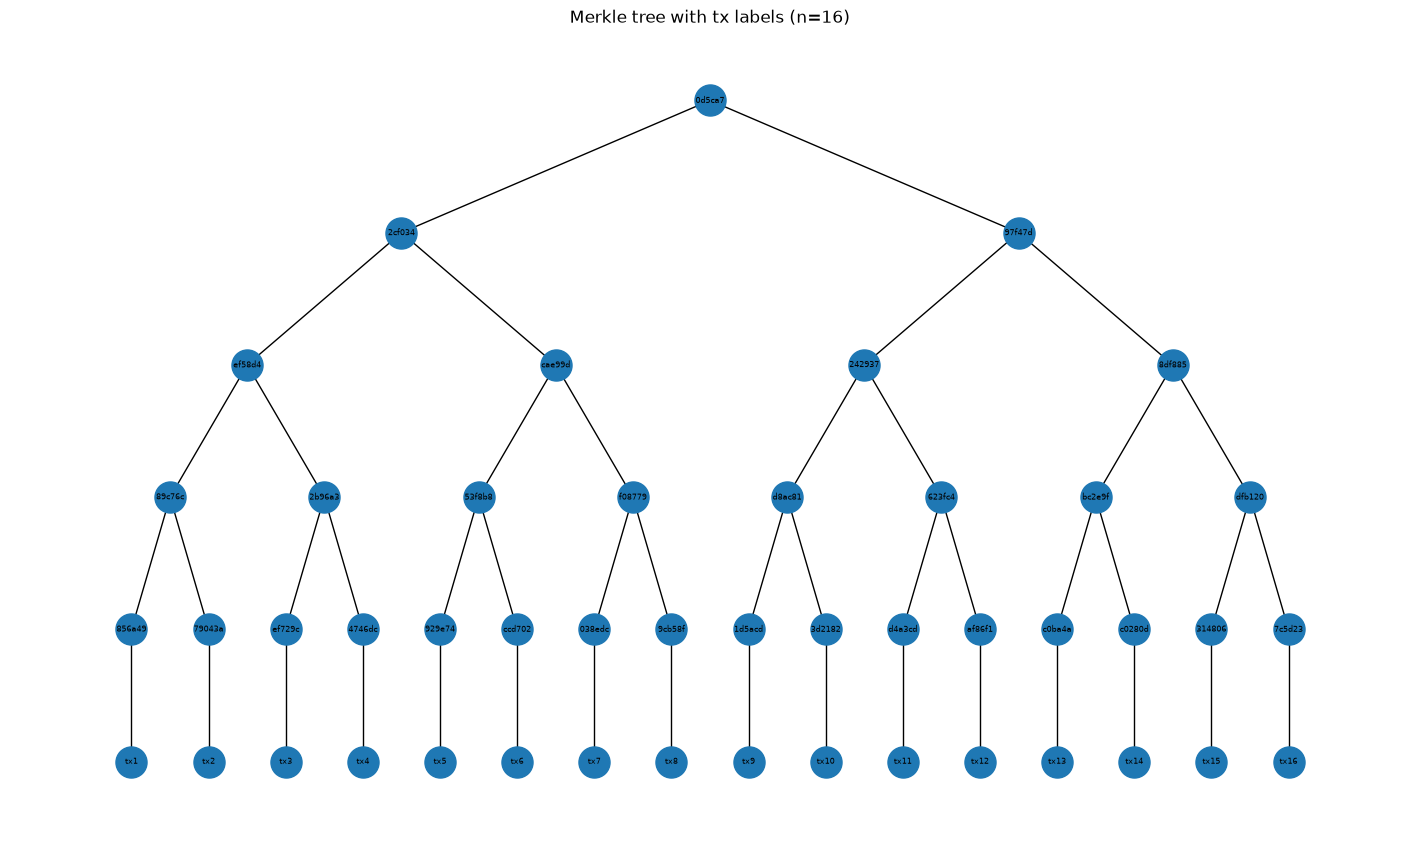

In [76]:
# draw 

import networkx as nx
import matplotlib.pyplot as plt

leaf_vals = [f"tx{i}".encode() for i in range(1, 17)]
children, hashes, root = build_merkle(leaf_vals)
n = len(leaf_vals)

G = nx.Graph()
for p, ks in children.items():
    for k in ks:
        G.add_edge(p, k)
for i in range(n):
    G.add_node(i)

label_id = {i: 10_000 + i for i in range(n)}
for i in range(n):
    G.add_node(label_id[i])
    G.add_edge(i, label_id[i])

pos = {}
xs = {i: i for i in range(n)}
pos.update({i: (xs[i], 0) for i in range(n)})

for p, (a, b) in children.items():
    ax, _ = pos[a]
    bx, _ = pos[b]
    pos[p] = ((ax + bx) / 2, max(pos[a][1], pos[b][1]) + 1)

for i in range(n):
    pos[label_id[i]] = (pos[i][0], pos[i][1] - 1)

plt.figure(figsize=(14, 8))
nx.draw(G, pos, node_size=500, with_labels=False)

labels = {}
for i in range(n):
    labels[i] = hashes[i].hex()[:6]                    # leaf hash
    labels[label_id[i]] = f"tx{i+1}"                   # tx label below it
for p in children:
    labels[p] = hashes[p].hex()[:6]                    # internal hashes

nx.draw_networkx_labels(G, pos, labels=labels, font_size=6)

plt.axis("off")
plt.title("Merkle tree with tx labels (n=16)")
plt.show()

## Problem 3 (5 points). Fork rate and main chain

Two miners are the only maintainers of the network. Each miner needs a random time to generate a new block which is modeled as exponential random variables with the rates $1/t_1$ and $1/t_2$ correspondingly. I.e. each miner generates Poisson point process of new blocks. The network is not ideal and it takes a random time to synchronize the block. The synchronization is modeled as an exponential random variable with the rate $1/t_0$. We assume both miners be honest and continue the longest known chain.

*Note.* The Poisson point process has memoryless and superposition properties [1]. So we can model three Poisson point processes independently and omit synchronization events if already synced.

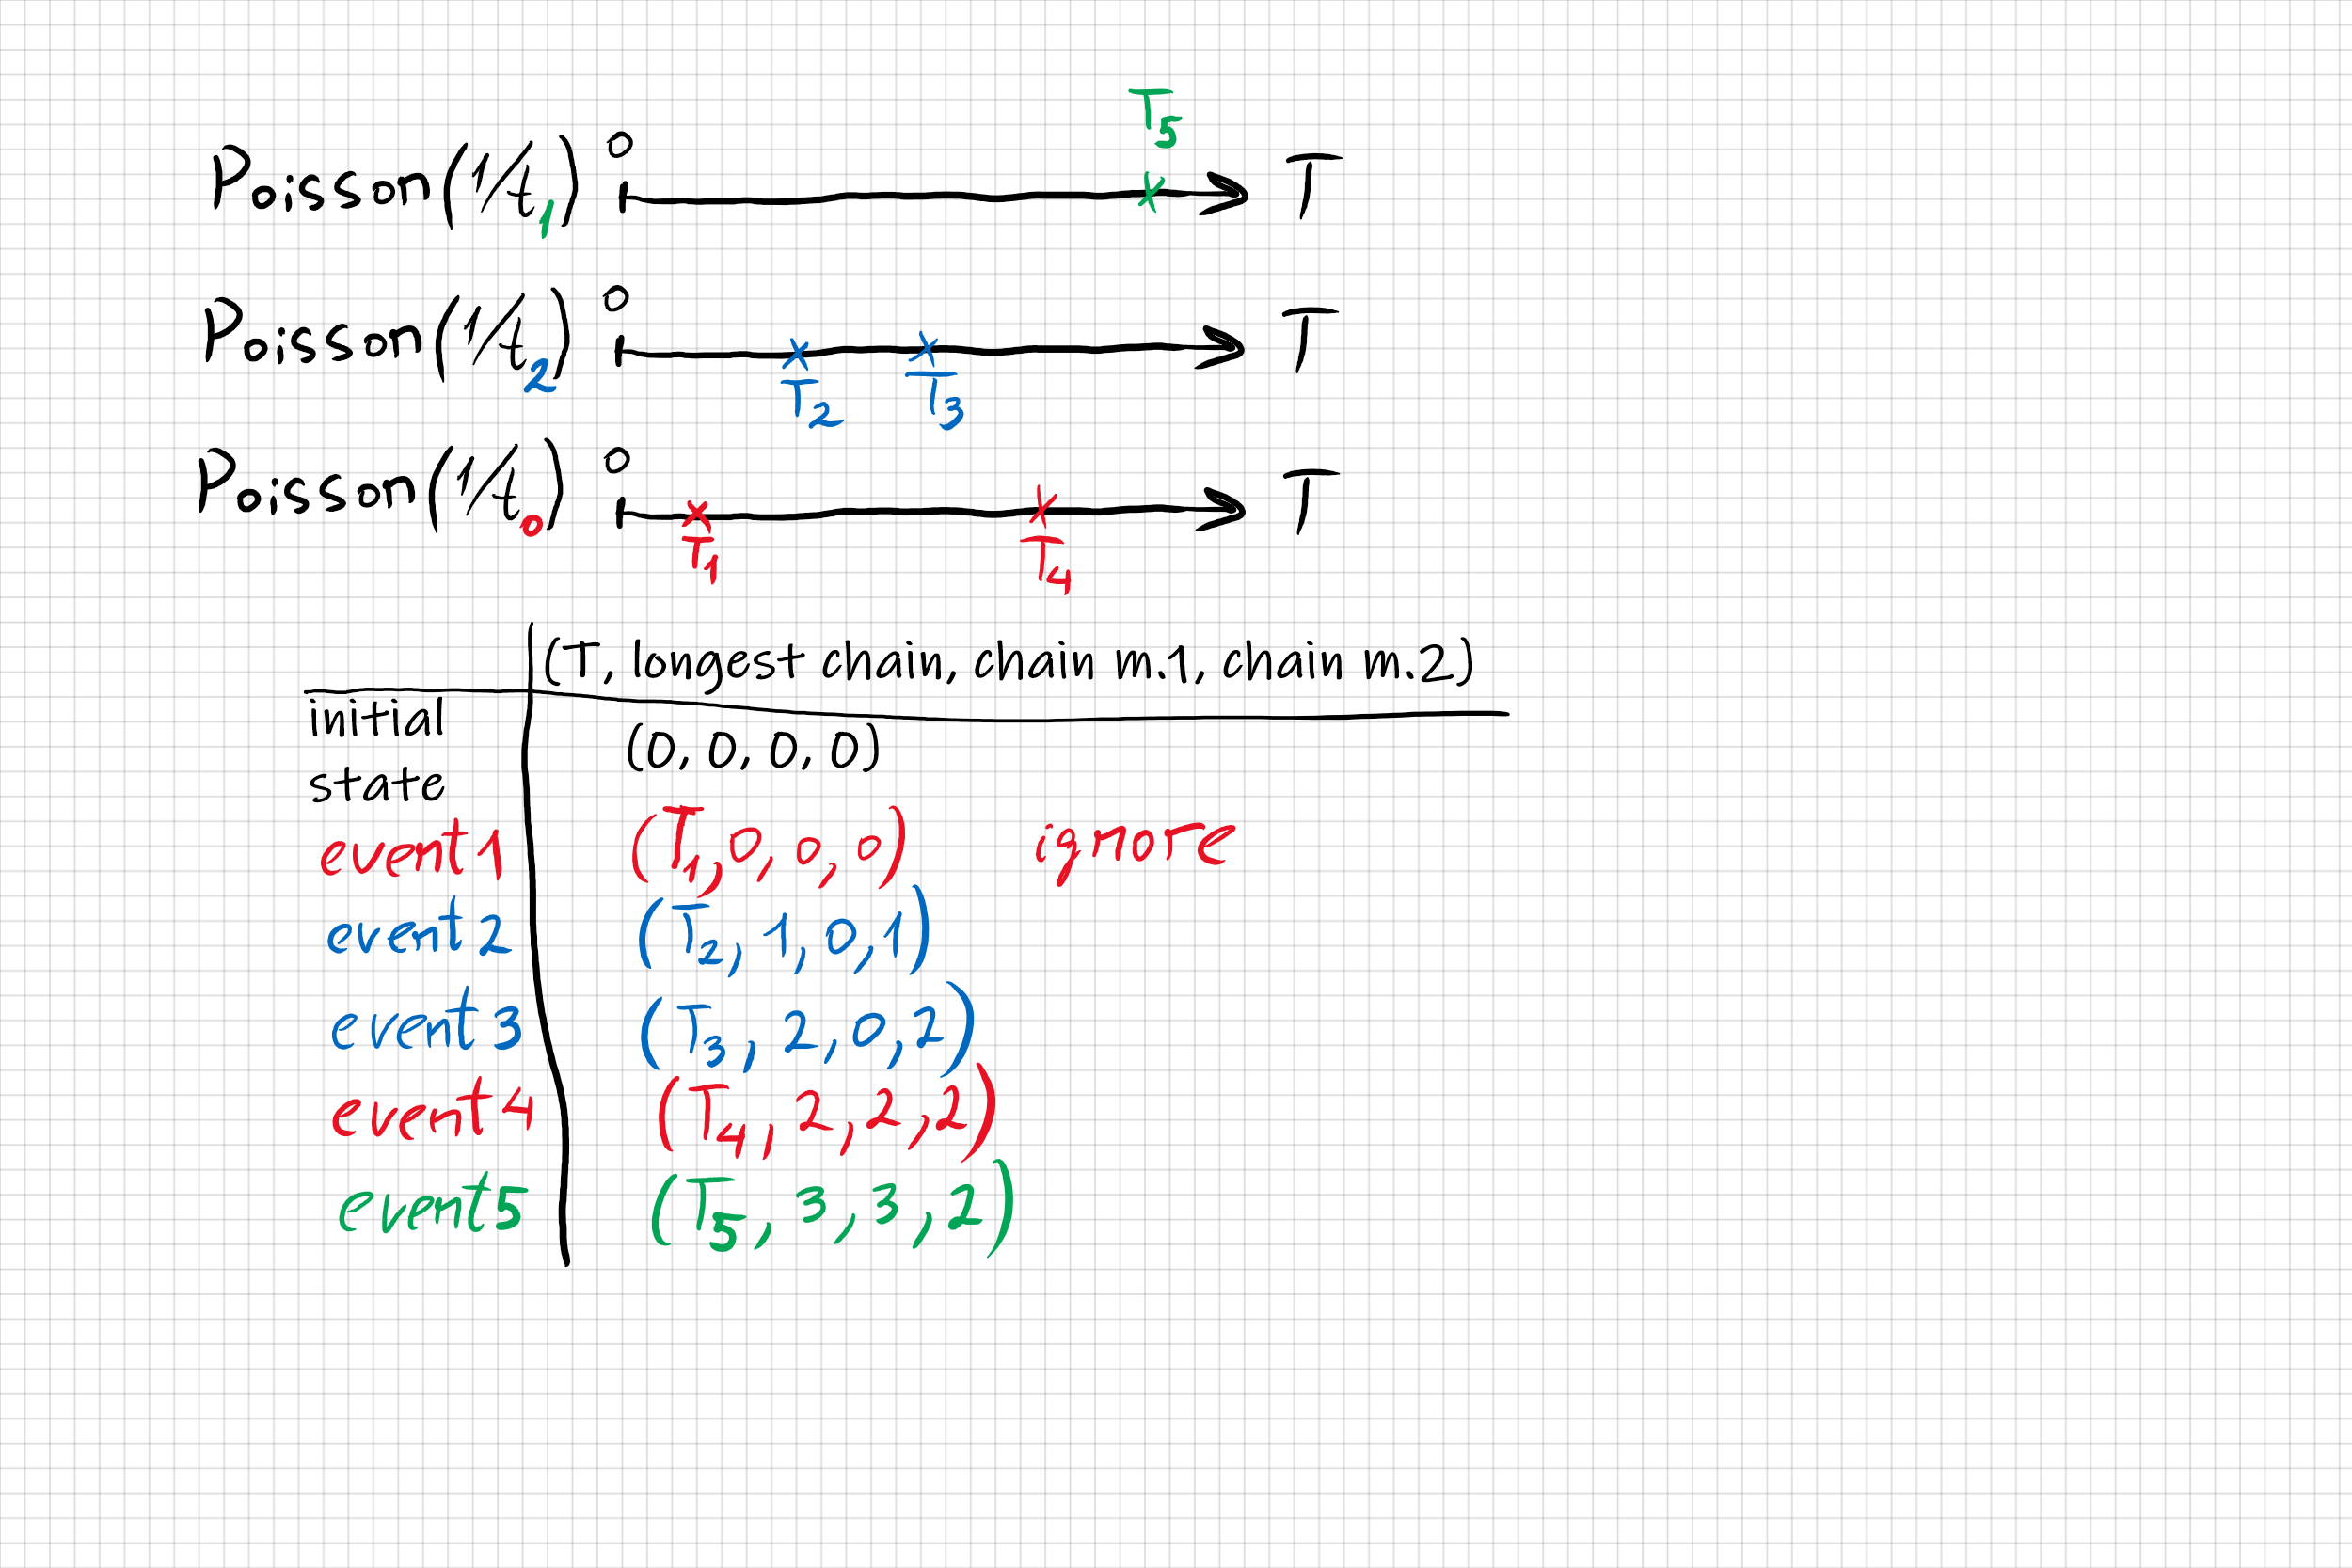

\[1\] Daley, Daryl J.; Vere-Jones, David (2003). An Introduction to the Theory of Point Processes: Volume I: Elementary Theory and Methods. Springer. ISBN 978-1475781090.

1) Implement a function to generate a sequence of tuples (time, longest chain, longest chain for miner 1, longest chain for miner 2) and run it for $t_1=t_2=1, t_0=0.5$ (1 point)

In [ ]:
# code

import numpy as np
import scipy.stats

# rate = average amount of blocks per second 
# While the exponential distribution (continuous version of a geometric distribution) measures the continuous waiting time between events, the Poisson distribution flips the perspective and counts the total number of successes in a locked window. Both rely on the exact same rate parameter, λ.
def poisson_event_times(rate, T):
    """Event times of a Poisson process with the given rate on [0, T]."""
    n = scipy.stats.poisson(rate * T).rvs() # How many blocks are mined in time T ? 
    return sorted(scipy.stats.uniform.rvs(loc=0, scale=T, size=n))

def simulate(t1, t2, t0, T=10.0, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # events for each process
    m1   = poisson_event_times(1/t1, T)
    m2   = poisson_event_times(1/t2, T)
    sync = poisson_event_times(1/t0, T)

    # merge into a single sorted timeline of (time, kind)
    events = [(t, 'm1') for t in m1] + \
             [(t, 'm2') for t in m2] + \
             [(t, 's')  for t in sync]
    events.sort()

    L1 = L2 = 0
    out = []
    for t, kind in events:
        if kind == 'm1':
            L1 += 1
        elif kind == 'm2':
            L2 += 1
        else:
            L1 = L2 = max(L1, L2)
        out.append((t, max(L1, L2), L1, L2))
    return out

# run
for row in simulate(t1=1.0, t2=1.0, t0=0.5, T=10.0, seed=42):
    print(f"t={row[0]:.3f}  max={row[1]}  m1={row[2]}  m2={row[3]}") 

t=0.206  max=1  m1=1  m2=0
t=0.344  max=1  m1=1  m2=1
t=0.465  max=1  m1=1  m2=1
t=0.581  max=2  m1=2  m2=1
t=0.651  max=2  m1=2  m2=2
t=0.977  max=2  m1=2  m2=2
t=1.220  max=2  m1=2  m2=2
t=1.395  max=3  m1=2  m2=3
t=1.560  max=3  m1=3  m2=3
t=1.560  max=4  m1=4  m2=3
t=1.705  max=4  m1=4  m2=4
t=1.818  max=5  m1=5  m2=4
t=1.834  max=6  m1=6  m2=4
t=2.123  max=7  m1=7  m2=4
t=2.912  max=7  m1=7  m2=5
t=2.921  max=7  m1=7  m2=6
t=3.046  max=7  m1=7  m2=7
t=3.664  max=8  m1=7  m2=8
t=4.319  max=9  m1=7  m2=9
t=4.402  max=9  m1=9  m2=9
t=4.561  max=10  m1=9  m2=10
t=4.952  max=10  m1=10  m2=10
t=5.924  max=10  m1=10  m2=10
t=6.011  max=11  m1=11  m2=10
t=6.075  max=11  m1=11  m2=11
t=6.119  max=12  m1=11  m2=12
t=6.842  max=12  m1=12  m2=12
t=7.081  max=13  m1=13  m2=12
t=7.852  max=13  m1=13  m2=13
t=8.084  max=13  m1=13  m2=13
t=8.324  max=14  m1=14  m2=13
t=8.662  max=15  m1=15  m2=13
t=9.093  max=15  m1=15  m2=15
t=9.489  max=15  m1=15  m2=15
t=9.656  max=15  m1=15  m2=15
t=9.699  ma

2) Plot the ratio of the blocks in the main chain to the number of generated blocks as a function of $t_0 \in (0, 2]$ for fixed $t_1=t_2=1$ (2 points)

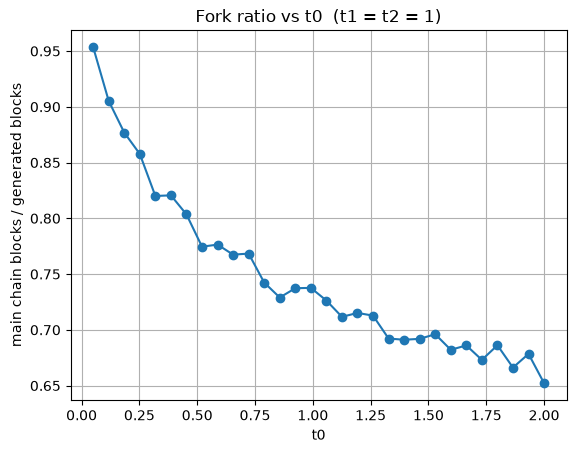

In [79]:
# code 

def ratio_for_t0(t0, t1=1.0, t2=1.0, T=100.0):
    m1   = [(t, 'm1') for t in poisson_event_times(1/t1, T)]
    m2   = [(t, 'm2') for t in poisson_event_times(1/t2, T)]
    sync = [(t, 's')  for t in poisson_event_times(1/t0, T)]
    events = sorted(m1 + m2 + sync)

    L1 = L2 = 0
    generated = 0
    for _, kind in events:
        if kind == 'm1':
            L1 += 1 
            generated += 1
        elif kind == 'm2':
            L2 += 1 
            generated += 1
        else:
            L1 = L2 = max(L1, L2)

    main = max(L1, L2)
    return main / generated if generated else 0.0

t0_values = np.linspace(0.05, 2.0, 30)
ratios = [np.mean([ratio_for_t0(t0) for _ in range(10)]) for t0 in t0_values]

plt.figure()
plt.plot(t0_values, ratios, marker='o')
plt.xlabel("t0")
plt.ylabel("main chain blocks / generated blocks")
plt.title("Fork ratio vs t0  (t1 = t2 = 1)")
plt.grid(True)
plt.show()

### Interesting! 

If Sync time t0 is small, there are less forks and the amount of surviving blocks is over 90%  

If t0 is large, there are more forks => more generated blocks are wasted (up to 35%) 

3) Let there be an adversary miner 3 with a rate $t_3 = 0.9$ and instant communication with miners 1 and 2. Let him mine his own branch. Plot the empirical probability to go $6$ blocks ahead of the miners' 1 and 2 main chain during $T=100$ as a function of $t_0$ for fixed $t_1=t_2=1$ (3 points)

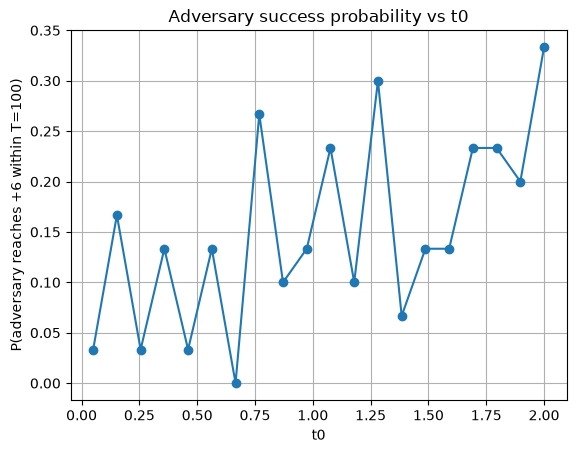

In [ ]:
# code

import numpy as np
import scipy.stats
import matplotlib.pyplot as plt 

def adversary_success(t0, t1=1.0, t2=1.0, t3=0.9, lead=6, T=100.0):
    m1   = [(t, 'm1') for t in poisson_event_times(1/t1, T)]
    m2   = [(t, 'm2') for t in poisson_event_times(1/t2, T)]
    m3   = [(t, 'm3') for t in poisson_event_times(1/t3, T)]
    sync = [(t, 's')  for t in poisson_event_times(1/t0, T)]
    events = sorted(m1 + m2 + m3 + sync)

    L1 = L2 = L3 = 0
    for _, kind in events:
        if kind == 'm1': L1 += 1
        elif kind == 'm2': L2 += 1
        elif kind == 'm3': L3 += 1
        else: L1 = L2 = max(L1, L2) # Sync event 
        if L3 >= max(L1, L2) + lead: # Miner 3 has no delay, so the check happens every time 
            return True
    return False

# sweep t0 over (0, 2]
t0_values = np.linspace(0.05, 2.0, 20)
probs = [np.mean([adversary_success(t0) for _ in range(30)]) for t0 in t0_values]

plt.figure()
plt.plot(t0_values, probs, marker='o')
plt.xlabel("t0")
plt.ylabel("P(adversary reaches +6 within T=100)")
plt.title("Adversary success probability vs t0")
plt.grid(True)
plt.show()

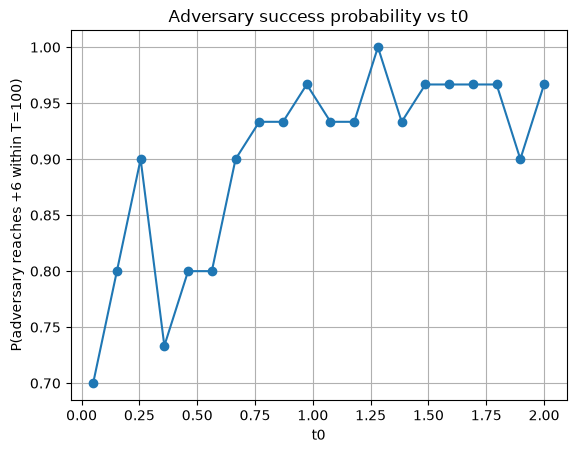

In [ ]:
# second case: adversary rebuilds on top of the honest chain only 

import numpy as np
import scipy.stats
import matplotlib.pyplot as plt 

def adversary_success(t0, t1=1.0, t2=1.0, t3=0.9, lead=6, T=100.0):
    m1   = [(t, 'm1') for t in poisson_event_times(1/t1, T)]
    m2   = [(t, 'm2') for t in poisson_event_times(1/t2, T)]
    m3   = [(t, 'm3') for t in poisson_event_times(1/t3, T)]
    sync = [(t, 's')  for t in poisson_event_times(1/t0, T)]
    events = sorted(m1 + m2 + m3 + sync)

    L1 = L2 = L3 = 0
    for _, kind in events:
        if kind == 'm1': L1 += 1
        elif kind == 'm2': L2 += 1
        elif kind == 'm3': L3 += 1
        else: L1 = L2 = max(L1, L2)

        # Adversary abandons its branch if the honest chain caught up.
        # It restarts from the honest head — no more wasted work.
        if L3 < max(L1, L2):
            L3 = max(L1, L2)

        if L3 >= max(L1, L2) + lead:
            return True
    return False

# sweep t0 over (0, 2]
t0_values = np.linspace(0.05, 2.0, 20)
probs = [np.mean([adversary_success(t0) for _ in range(30)]) for t0 in t0_values]

plt.figure()
plt.plot(t0_values, probs, marker='o')
plt.xlabel("t0")
plt.ylabel("P(adversary reaches +6 within T=100)")
plt.title("Adversary success probability vs t0")
plt.grid(True)
plt.show()